In [11]:
import kagglehub

path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dermnet' dataset.
Path to dataset files: /kaggle/input/dermnet


In [23]:
DERMNET_ROOT = "/kaggle/input/dermnet"
TRAIN_DIR = os.path.join(DERMNET_ROOT, "train")
TEST_DIR  = os.path.join(DERMNET_ROOT, "test")

print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)

Train dir: /kaggle/input/dermnet/train
Test dir : /kaggle/input/dermnet/test


In [24]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from collections import Counter

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [26]:
disease_classes = ["Acne", "Eczema", "Psoriasis", "Fungal", "Normal"]
class_to_idx = {c: i for i, c in enumerate(disease_classes)}

In [27]:
FOLDER_TO_CLASS = {
    # Acne
    "Acne and Rosacea Photos": "Acne",

    # Eczema / Dermatitis
    "Eczema Photos": "Eczema",
    "Atopic Dermatitis Photos": "Eczema",
    "Poison Ivy Photos and other Contact Dermatitis": "Eczema",

    # Psoriasis
    "Psoriasis pictures Lichen Planus and related diseases": "Psoriasis",

    # Fungal
    "Tinea Ringworm Candidiasis and other Fungal Infections": "Fungal",
    "Nail Fungus and other Nail Disease": "Fungal",

    # Normal / benign / non-target
    "Light Diseases and Disorders of Pigmentation": "Normal",
    "Seborrheic Keratoses and other Benign Tumors": "Normal"
}

In [28]:
class DermNetDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for folder, disease in FOLDER_TO_CLASS.items():
            folder_path = os.path.join(root_dir, folder)

            if not os.path.isdir(folder_path):
                print(f" Missing folder: {folder}")
                continue

            label = class_to_idx[disease]

            for img_name in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_name)
                try:
                    Image.open(img_path).verify()
                    self.samples.append((img_path, label))
                except:
                    pass

        print(f"Loaded {len(self.samples)} images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [29]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [30]:
train_ds = DermNetDataset(TRAIN_DIR, transform)
test_ds  = DermNetDataset(TEST_DIR, transform)

print("Train size:", len(train_ds))
print("Test size :", len(test_ds))

Loaded 8508 images from /kaggle/input/dermnet/train
Loaded 2233 images from /kaggle/input/dermnet/test
Train size: 8508
Test size : 2233


In [36]:
train_labels = [label for _, label in train_ds]
class_counts = Counter(train_labels)

print("Training distribution:")
for k, v in class_counts.items():
    print(disease_classes[k], "→", v)

sample_weights = [1.0 / class_counts[label] for label in train_labels]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

Training distribution:
Acne → 840
Eczema → 1984
Psoriasis → 1405
Fungal → 2340
Normal → 1939


In [37]:
class SkinDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        for name, p in self.backbone.named_parameters():
            p.requires_grad = "layer4" in name

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

In [38]:
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(len(disease_classes))],
    dtype=torch.float
).to(device)

model = SkinDiseaseModel(len(disease_classes)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)

In [40]:
from tqdm import tqdm

epochs = 15

for epoch in range(epochs):

    model.train()
    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}")


Epoch 1/15 | Avg Loss: 0.8995


Epoch 2/15 | Avg Loss: 0.6959


Epoch 3/15 | Avg Loss: 0.5982


Epoch 4/15 | Avg Loss: 0.5313


Epoch 5/15 | Avg Loss: 0.4618


...

Epoch 11/15 | Avg Loss: 0.2441


Epoch 12/15 | Avg Loss: 0.2203


Epoch 13/15 | Avg Loss: 0.1979


Epoch 14/15 | Avg Loss: 0.1864


Epoch 15/15 | Avg Loss: 0.1904


In [54]:
from sklearn.metrics import classification_report
import torch.nn.functional as F

model.eval()
all_preds, all_labels = [], []

CONF_THRESHOLD = 0.7
normal_idx = disease_classes.index("Normal")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=disease_classes))


              precision    recall  f1-score   support

        Acne       0.80      0.96      0.88       312
      Eczema       0.77      0.71      0.74       497
   Psoriasis       0.63      0.66      0.65       352
      Fungal       0.78      0.75      0.76       586
      Normal       0.77      0.74      0.75       486

    accuracy                           0.75      2233
   macro avg       0.75      0.76      0.76      2233
weighted avg       0.75      0.75      0.75      2233



In [53]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image)

        probs = torch.softmax(outputs, dim=1)

        max_prob, pred_idx = torch.max(probs, dim=1)

        max_prob = max_prob.item()
        pred_idx = pred_idx.item()

    if max_prob < CONF_THRESHOLD:
        prediction = "Unknown"
    else:
        prediction = disease_classes[pred_idx]

    return prediction, max_prob

In [67]:
prediction, confidence = predict_image("img1.jfif")

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: Acne
Confidence: 0.9995347261428833


In [69]:
os.makedirs("model", exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": disease_classes
    },
    "model/skin_dermnet_model.pth"
)

print("Model saved")

Model saved


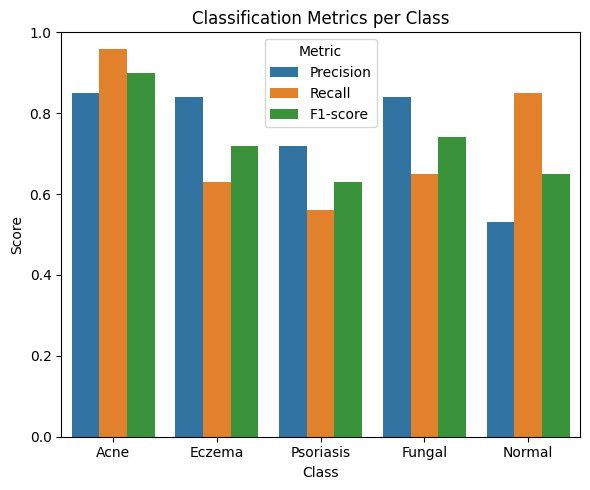

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Class": ["Acne", "Eczema", "Psoriasis", "Fungal", "Normal"],
    "Precision": [0.85, 0.84, 0.72, 0.84, 0.53],
    "Recall":    [0.96, 0.63, 0.56, 0.65, 0.85],
    "F1-score":  [0.90, 0.72, 0.63, 0.74, 0.65]
}

df = pd.DataFrame(data)

df_melted = df.melt(id_vars="Class", var_name="Metric", value_name="Score")

plt.figure(figsize=(6, 5))
sns.barplot(data=df_melted, x="Class", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Classification Metrics per Class")
plt.ylabel("Score")
plt.xlabel("Class")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


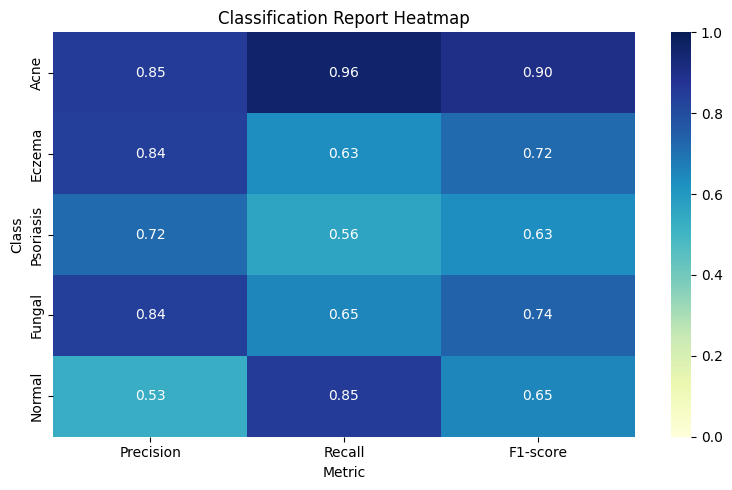

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Precision": [0.85, 0.84, 0.72, 0.84, 0.53],
    "Recall":    [0.96, 0.63, 0.56, 0.65, 0.85],
    "F1-score":  [0.90, 0.72, 0.63, 0.74, 0.65]
}, index=["Acne", "Eczema", "Psoriasis", "Fungal", "Normal"])

plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f", vmin=0, vmax=1)
plt.title("Classification Report Heatmap")
plt.ylabel("Class")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4204511660.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


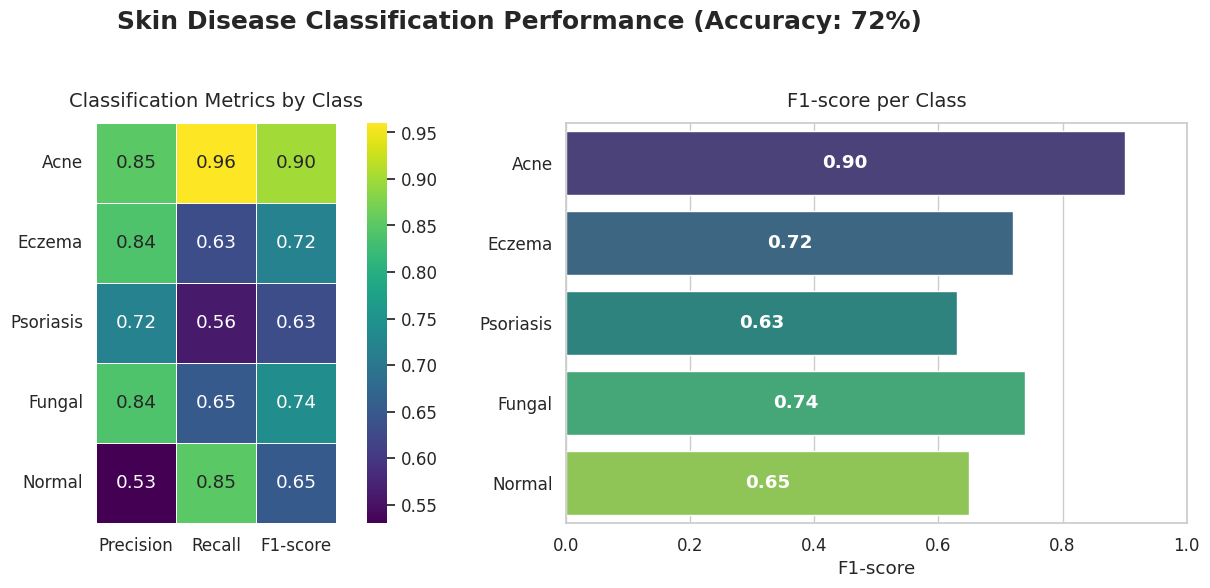

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

classes = ["Acne", "Eczema", "Psoriasis", "Fungal", "Normal"]

metrics = pd.DataFrame({
    "Precision": [0.85, 0.84, 0.72, 0.84, 0.53],
    "Recall":    [0.96, 0.63, 0.56, 0.65, 0.85],
    "F1-score":  [0.90, 0.72, 0.63, 0.74, 0.65],
}, index=classes)

support = np.array([312, 497, 352, 586, 486])
accuracy = 0.72

sns.set_theme(style="whitegrid", font_scale=1.1)
cmap = sns.color_palette("viridis", as_cmap=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [1, 1]}
)

ax0, ax1 = axes

sns.heatmap(
    metrics,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    linewidths=0.6,
    cbar=True,
    square=True,
    ax=ax0,
    annot_kws={"ha": "center", "va": "center"}
)

ax0.set_title("Classification Metrics by Class", fontsize=14, pad=12)
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.tick_params(axis="y", rotation=0)

sns.barplot(
    x=metrics["F1-score"],
    y=metrics.index,
    palette="viridis",
    ax=ax1
)

ax1.set_xlim(0, 1)
ax1.set_title("F1-score per Class", fontsize=14, pad=12)
ax1.set_xlabel("F1-score")
ax1.set_ylabel("")

for i, val in enumerate(metrics["F1-score"]):
    ax1.text(
        val / 2,
        i,
        f"{val:.2f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )

fig.suptitle(
    "Skin Disease Classification Performance (Accuracy: 72%)",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()